# Optimizing AI Trading Algorithms


In this project I will optimize various aspects of a machine learning model for 
predicting stock price movements. This will integrate concepts such as data 
preprocessing and cleaning, hyperparameter tuning, detecting and addressing 
over-/under-fitting, model evaluation, and feature selection techniques. 
The goal is not necessarily to build a "winning" trading _strategy_. 
The goal is to use the tools, techniques, concepts and insights needed to evaluate, 
optimize and monitor *my own* trading strategies.


## The Scenario

I am an analyst at a boutique investment firm tasked with coming up with a novel 
idea for investing in specific sectors of the industry. I've heard that the Utilities, 
Consumer Staples and Healthcare sectors are relatively resilient to economic shocks 
and recessions, and that stock market investors tend to flock to these sectors 
in times of uncertainty. 

I decided to take the [SPDR Healthcase Sector ETF (NYSEARCA: XLV)](https://www.sectorspdrs.com/mainfund/XLV) and try to model 
its returns' dynamics using a machine learning AI strategy. 
My idea is to get data for the volatility index [(INDEXCBOE: VIX)](https://www.cboe.com/tradable_products/vix/) as a proxy for uncertainty 
in the market. I also decide to take a look at [Google Trends data](https://trends.google.com/trends/explore?date=all&geo=US&q=recession) for the search term "recession" 
in the United States, in order to try and see if there is any meaningful relationship 
between the general public's level of concern about a recession happening and the 
price movements of the Health Care Select Sector SPDR Fund.


I've decided to train a binary **classification** model that merely attempts to 
predict the **direction** of XLV's 5-day price movements. 
In other words, I want to see if on any given day, with the above data in hand, 
I could reliably predict whether the price of XLV will increase or decrease over 
the next 5 trading days.

## Notebook Imports

In [1]:
# %pip install --upgrade pip yfinance ta --quiet

In [2]:
#---------IMPORTS------------#
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import yfinance as yf
from plotly.subplots import make_subplots
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, learning_curve, train_test_split
from ta.momentum import RSIIndicator
from ta.volatility import BollingerBands

pd.options.display.max_columns = 50
pd.options.display.max_rows = 50

#---------CONTANTS------------#

RANDOM_SEED = 42

## 1. Data Acquisition, Exploration, Cleaning and Preprocessing


In this section, I download and inspect:

- daily data for the SPDR Healthcase Sector ETF (NYSEARCA: XLV)
- daily data for the volatility index (INDEXCBOE: VIX)
- monthly data from Google Trends for the search interest in the term "recession" in the United States

The goal is to make sure the data is clean, meaningful, and usable for selecting and engineering features.


### 1.1. Price and Volume Data for "XLV"


I have downloded daily data from **January 1st, 2004** to **March 31st, 2024** for the ticker **XLV** 
using the `yfinance` library and stored it in a CSV file named `xlv_data.csv`. 
I load this data into a Pandas DataFrame named `xlv_data`, setting the index column 
to the first column of the CSV file (`Date`) and setting `parse_dates=True`.


In [3]:
xlv_data = pd.read_csv("../data/raw/xlv_data.csv", parse_dates=True, index_col="Date")
print(xlv_data)

                  Open        High         Low       Close   Adj Close  \
Date                                                                     
2004-01-02   30.200001   30.440001   30.120001   30.219999   21.567184   
2004-01-05   30.400000   30.500000   30.139999   30.360001   21.667091   
2004-01-06   30.469999   30.480000   30.309999   30.450001   21.731337   
2004-01-07   30.450001   30.639999   30.309999   30.639999   21.866926   
2004-01-08   30.700001   30.700001   30.320000   30.510000   21.774158   
...                ...         ...         ...         ...         ...   
2024-03-22  145.850006  146.220001  145.259995  145.440002  145.440002   
2024-03-25  145.710007  145.860001  145.009995  145.240005  145.240005   
2024-03-26  145.529999  145.940002  145.139999  145.770004  145.770004   
2024-03-27  147.009995  147.710007  146.619995  147.710007  147.710007   
2024-03-28  147.919998  148.229996  147.679993  147.729996  147.729996   

             Volume  
Date           

The `info()` and `describe()` methods provide an overview of how many rows 
of data there are in `xlv_data`, what columns are present and what their data 
types are, and what some basic statistics (mean, std, quartiles, min/max values) 
of the columns look like.


In [4]:
# use info() method
xlv_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5094 entries, 2004-01-02 to 2024-03-28
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       5094 non-null   float64
 1   High       5094 non-null   float64
 2   Low        5094 non-null   float64
 3   Close      5094 non-null   float64
 4   Adj Close  5094 non-null   float64
 5   Volume     5094 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 278.6 KB


In [5]:
# view summary statistics
xlv_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,5094.0,6.534231e+01,3.669535e+01,22.010000,3.199000e+01,5.710000e+01,9.065750e+01,1.479200e+02
High,5094.0,6.573040e+01,3.691585e+01,22.290001,3.213250e+01,5.740000e+01,9.107750e+01,1.482700e+02
Low,5094.0,6.492420e+01,3.647787e+01,21.629999,3.181250e+01,5.668000e+01,8.992750e+01,1.476800e+02
Close,5094.0,6.534910e+01,3.671247e+01,21.879999,3.199000e+01,5.701000e+01,9.055750e+01,1.478600e+02
Adj Close,5094.0,5.824230e+01,3.793222e+01,16.812475,2.450857e+01,4.838700e+01,8.294131e+01,1.477300e+02
Volume,5094.0,7.228951e+06,5.445803e+06,58700.000000,3.790550e+06,6.582850e+06,9.559550e+06,6.647020e+07


How many `NaN` rows are there in `xlv_data`?


In [6]:
answer = xlv_data.isna().sum()
answer

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Take a look at the final five rows of `xlv_data`.


In [7]:
xlv_data.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-03-22,145.850006,146.220001,145.259995,145.440002,145.440002,5537200
2024-03-25,145.710007,145.860001,145.009995,145.240005,145.240005,5253000
2024-03-26,145.529999,145.940002,145.139999,145.770004,145.770004,6942400
2024-03-27,147.009995,147.710007,146.619995,147.710007,147.710007,8797400
2024-03-28,147.919998,148.229996,147.679993,147.729996,147.729996,8090200


Raw OHLC data is not suitable for training models. The absolute price level of 
a security is boundless in theory and not particularly menaningful. 
In the next section, I engineer useful features from all of these columns. 

As a visual sanity check, I plot `Adj Close` as a line plot.


<Axes: xlabel='Date'>

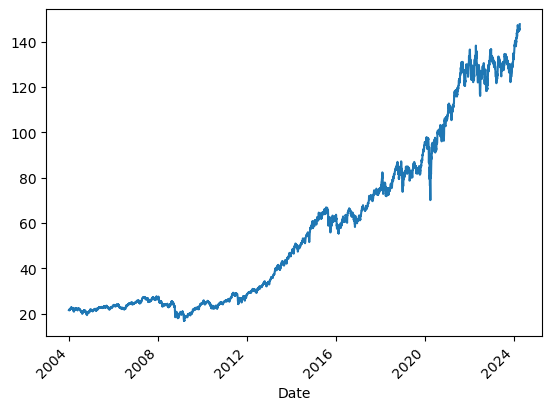

In [8]:
# visualise Adj Close
xlv_data["Adj Close"].plot(rot=45)

**Bonus**: The cell below plots the combined candlestick + volume chart for the last 15 months of data using Plotly.


In [9]:
data_since_2023 = xlv_data["2023-01-01":]

figure = make_subplots(specs=[[{"secondary_y": True}]])
figure.add_traces(
    go.Candlestick(
        x=data_since_2023.index,
        open=data_since_2023.Open,
        high=data_since_2023.High,
        low=data_since_2023.Low,
        close=data_since_2023.Close,
    ),
    secondary_ys=[True],
)
figure.add_traces(
    go.Bar(x=data_since_2023.index, y=data_since_2023.Volume, opacity=0.5),
    secondary_ys=[False],
)

figure.update_layout(
    title="XLV Candlestick Chart Since 2023",
    xaxis_title="Date",
    yaxis_title="Volume",
    yaxis2_title="Price",
    showlegend=False,
)
figure.update_yaxes(fixedrange=False)
figure.layout.yaxis2.showgrid = False
figure.show()

### 1.2. Data for The Volatility Index `VIX`


As before, I downloadeded daily data for the volatility index [(INDEXCBOE: VIX)](https://www.cboe.com/tradable_products/vix/) over 
the same time period using `yfinance` and saved it as a CSV file named `vix_data.csv`. 
I load the data into a variable named `vix_data` setting the index and parse the dates correctly.

In [10]:
vix_data = pd.read_csv("../data/raw/vix_data.csv", parse_dates=True, index_col="Date")
vix_data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2004-01-02,17.959999,18.68,17.540001,18.219999,18.219999,0
2004-01-05,18.450001,18.49,17.440001,17.490000,17.490000,0
2004-01-06,17.660000,17.67,16.190001,16.730000,16.730000,0
2004-01-07,16.719999,16.75,15.500000,15.500000,15.500000,0
2004-01-08,15.420000,15.68,15.320000,15.610000,15.610000,0


Plot a line chart of the `Adj Close` value of the VIX.


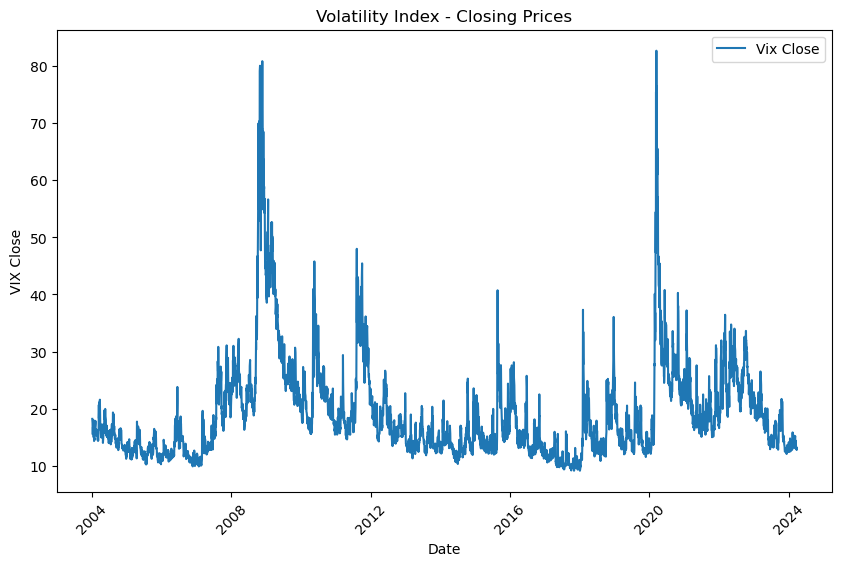

In [11]:
# Plot the Adj Close with a line chart
plt.figure(figsize=(10, 6))
plt.plot(vix_data["Adj Close"], label="Vix Close")
plt.title("Volatility Index - Closing Prices")
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.ylabel("VIX Close")
plt.legend()
plt.show()

### 1.3. Google Trends Data


The **monthly** evolution of search interest in the term "recession" in the U.S. 
over the period of interest (Jan. 2003 - Mar. 2024) from the Google Trends website 
has been downloaded as a CSV file. I load this data using Pandas into a DataFrame 
named `google_trends_data`, set the index column of the DataFrame to the "`Month`" 
column from the CSV and have Pandas try and parse these dates automatically.

> PS: The "Month" column in the CSV is in "YYYY-MM" format.


In [12]:
google_trends_data = pd.read_csv("../data/raw/GoogleTrendsData.csv", parse_dates=True, index_col="Month")
google_trends_data.head()

,recession_search_trend
Month,
2004-01-01,4
2004-02-01,4
2004-03-01,5
2004-04-01,6
2004-05-01,4


As noted above, the CSV lists **monthly** search trends data and the `Month` column 
is in YYYY-MM format. Review how has Pandas interpreted and parsed these into specific 
dates?

In [13]:
google_trends_data.index

DatetimeIndex(['2004-01-01', '2004-02-01', '2004-03-01', '2004-04-01',
               '2004-05-01', '2004-06-01', '2004-07-01', '2004-08-01',
               '2004-09-01', '2004-10-01',
               ...
               '2023-06-01', '2023-07-01', '2023-08-01', '2023-09-01',
               '2023-10-01', '2023-11-01', '2023-12-01', '2024-01-01',
               '2024-02-01', '2024-03-01'],
              dtype='datetime64[ns]', name='Month', length=243, freq=None)

I want to assign the data points to the last day of the respective months, as this 
data would have been available at the _end_ of each period. 
Shift the index column of `google_trends_data` to do this.

In [14]:
google_trends_data.index = google_trends_data.index + pd.offsets.MonthEnd()
google_trends_data.index

DatetimeIndex(['2004-01-31', '2004-02-29', '2004-03-31', '2004-04-30',
               '2004-05-31', '2004-06-30', '2004-07-31', '2004-08-31',
               '2004-09-30', '2004-10-31',
               ...
               '2023-06-30', '2023-07-31', '2023-08-31', '2023-09-30',
               '2023-10-31', '2023-11-30', '2023-12-31', '2024-01-31',
               '2024-02-29', '2024-03-31'],
              dtype='datetime64[ns]', name='Month', length=243, freq=None)

The cell below visualizes this data as a line plot.

> **Note from Google:** "Numbers represent search interest relative to the highest 
> point on the chart for the given region and time. A value of 100 is the peak 
> popularity for the term. A value of 50 means that the term is half as popular. 
> A score of 0 means there was not enough data for this term."


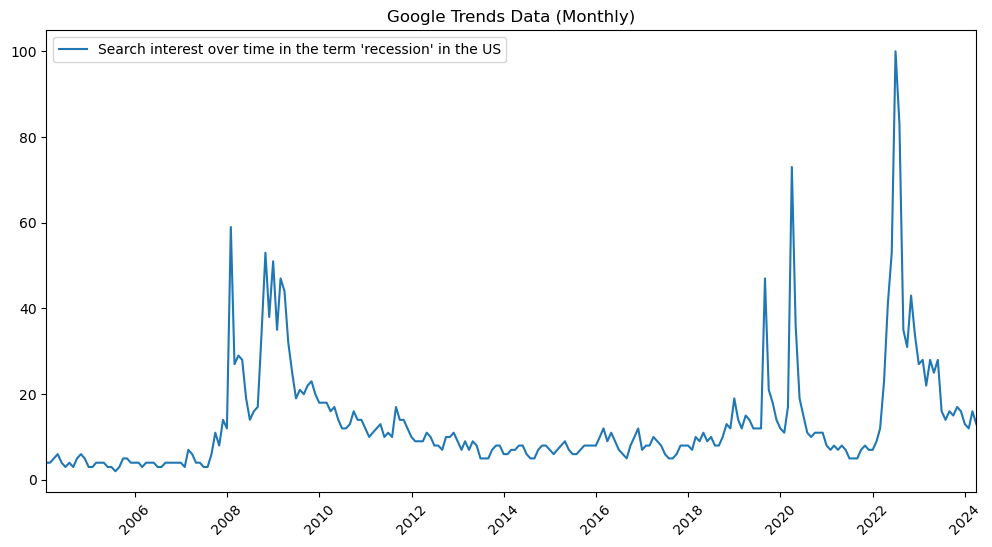

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(google_trends_data)
date_fmt = mdates.DateFormatter("%Y-%m")
plt.xlim(google_trends_data.index[0], google_trends_data.index[-1])
plt.xticks(rotation=45)
plt.title("Google Trends Data (Monthly)")
plt.legend(["Search interest over time in the term 'recession' in the US"])
plt.show()

Not every month-end is a trading day. Also, what value should the model train 
on for all the days in between month-ends? 

Below, I convert the monthly data to daily and interpolate the end-of-month values 
to get all the in-between values. 
I will use this new `google_trends_daily` data going forward.

In [16]:
google_trends_daily = google_trends_data.resample('D').asfreq().interpolate(method='linear')

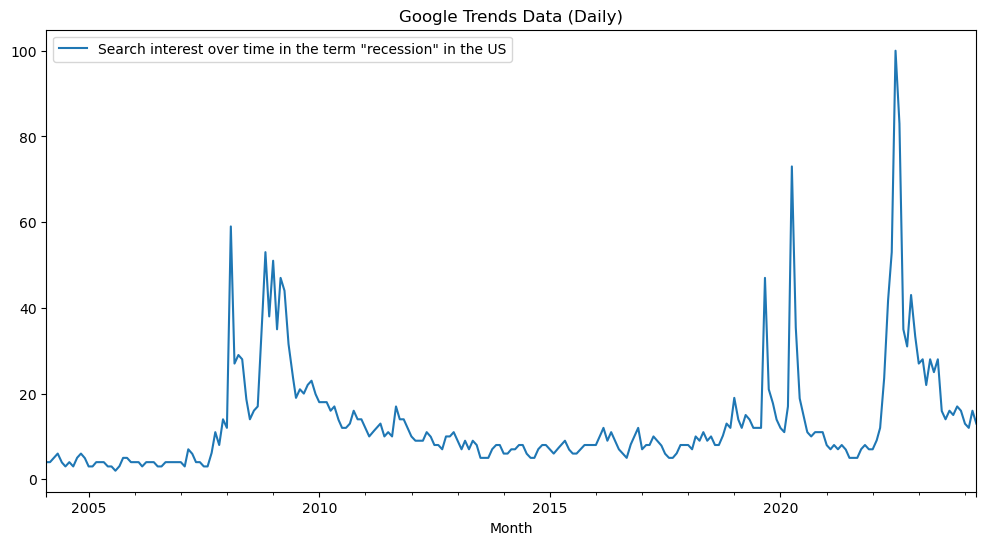

In [17]:
# # The shape of the chart should not have changed
google_trends_daily.plot.line(title="Google Trends Data (Daily)", figsize=(12, 6)).legend(
    labels=['Search interest over time in the term "recession" in the US']
);

## 2. Feature Engineering and Analysis


In this section, I will create a new DataFrame called `data` which will house 
all of the features as well as the prediction target. I will then analyze the 
features and look for potentially problematic features.

First, I will instantiate an empty DataFrame called `data` with just an index 
that matches `XLV`'s.

In [18]:
data = pd.DataFrame(index=xlv_data.index)
data.head()

""
Date
2004-01-02
2004-01-05
2004-01-06
2004-01-07
2004-01-08


### 2.1. Feature Engineering


#### 2.1.1. Month and Weekday


Add the `month` and `weekday` columns to `data` as categorical features (integer labels) from its index.


In [19]:
# add month and weekday columns
data["month"] = data.index.to_series().dt.month
data["weekday"] = data.index.to_series().dt.weekday # Mon=0, Sun=6

I do not want to train a model using these columns as they are, because the 
numbers themselves and the inherent "order" of months and weekdays do not really 
have any significance, but the model may interpret them as meaningful. 

I could either 
1. Use one-hot encoding to turn each category to a separate binary feature, or 
2. Treat them as cyclical features. 

The choice is somewhat arbitrary and depends on how important a "feature" I 
believe the cyclicality to be.

Below, I will:

- Treat `month` as a cyclical feature, creating two features (`month_sin` and `month_cos`).
(👉 See: [Trigonometric features](https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html#trigonometric-features))
- One-hot-encode `weekday` and create five additional features of type `int32` 
(one for each business day) with the `weekday` prefix. (👉 See: [`pandas.get_dummies()`](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html))
- Make sure the original `month` and `weekday` columns are no longer present in `data`. (`drop()` them if necessary.)


In [20]:
# Treat `month` as a "cyclical" feature with a period of 12 months.
PERIOD = 12
data["month_sin"] = np.sin(data["month"] / PERIOD * 2 * np.pi)
data["month_cos"] = np.cos(data["month"] / PERIOD * 2 * np.pi)

# Drop the original `month` column.
data.drop(columns="month", inplace=True)

# Treat `weekday` as a "categorical" feature and one-hot-encode it dropping the first redundant column.
data = pd.get_dummies(data, columns=["weekday"], prefix="weekday", drop_first=True)

In [21]:
data.head()

,month_sin,month_cos,weekday_1,weekday_2,weekday_3,weekday_4
Date,,,,,,
2004-01-02,0.5,0.866025,False,False,False,True
2004-01-05,0.5,0.866025,False,False,False,False
2004-01-06,0.5,0.866025,True,False,False,False
2004-01-07,0.5,0.866025,False,True,False,False
2004-01-08,0.5,0.866025,False,False,True,False


#### 2.1.2. Historical Returns


Next, I add features for historical returns of the XLV ETF from its `Adj Close` column. 
For each date, calculate rolling **simple** returns over the past 1, 5, 10 and 20 days. 
Create 4 columns in `data` named `ret_#d_hist` where `#` is the lookback period. 

In [22]:
# Create features for 1-day, 5-day, 10-day and 20-day historical returns
hist_ret_lookbacks = [1, 5, 10, 20]
# iterate through list and create rolling returns
for period in hist_ret_lookbacks:
    data[f"ret_{period}d_hist"] = xlv_data["Adj Close"].pct_change(period)
  
data.head()

,month_sin,month_cos,weekday_1,weekday_2,weekday_3,weekday_4,ret_1d_hist,ret_5d_hist,ret_10d_hist,ret_20d_hist
Date,,,,,,,,,,
2004-01-02,0.5,0.866025,False,False,False,True,NaN,NaN,NaN,NaN
2004-01-05,0.5,0.866025,False,False,False,False,0.004632,NaN,NaN,NaN
2004-01-06,0.5,0.866025,True,False,False,False,0.002965,NaN,NaN,NaN
2004-01-07,0.5,0.866025,False,True,False,False,0.006239,NaN,NaN,NaN
2004-01-08,0.5,0.866025,False,False,True,False,-0.004242,NaN,NaN,NaN


The cell below plots the histograms of the returns I just calculated. 
They should look normally distributed around zero.


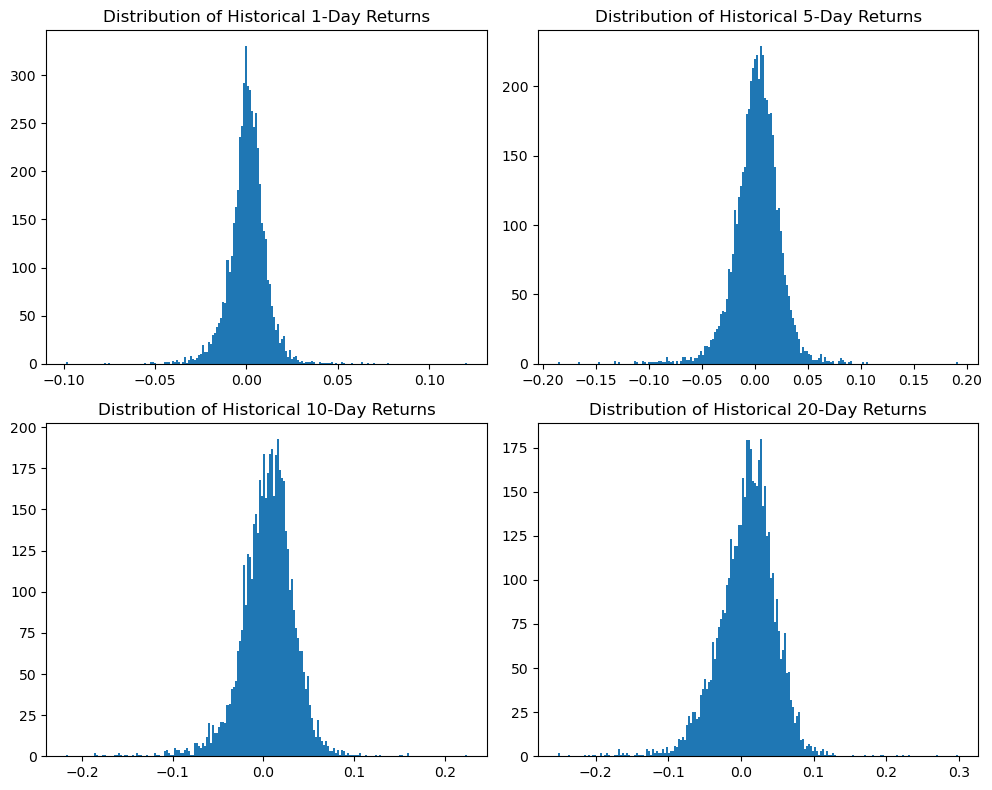

In [23]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))


def plot_hist_returns(ax, data, col, title):
    ax.hist(data[col], bins=200)
    ax.set_title(title)


for i, n_days in enumerate(hist_ret_lookbacks):
    plot_hist_returns(
        axs[i // 2, i % 2], data, f"ret_{n_days}d_hist", f"Distribution of Historical {n_days}-Day Returns"
    )

plt.tight_layout()
plt.show()

#### 2.1.3. Trade Volumes

As trading volumes span several orders of magnitude, take the natural logarithm 
of `Volume` and use it as a feature instead. This helps emphasize variations in 
its lower range. 

**Note:** For tree-based models such as Decision Trees and Random Forests, scaling 
is not necessary. But feature scaling becomes critically important if using other 
model types (e.g. distance-based models).


In [24]:
data["log_volume"] = np.log(xlv_data["Volume"])

#### 2.1.4. Technical Indicators

I add a feature named `ibs` which is calculated as (Close - Low) / (High - Low). 
This measure, a number between zero and one and sometimes referred to as the 
"Internal Bar Strength", denotes how "strong" the closing price is relative to 
the high and low prices within the same period.
> **NB:** Remember to use `Close` (not `Adj Close`).

In [25]:
xlv_data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2004-01-02,30.200001,30.440001,30.120001,30.219999,21.567184,628700
2004-01-05,30.400000,30.500000,30.139999,30.360001,21.667091,191500
2004-01-06,30.469999,30.480000,30.309999,30.450001,21.731337,289300
2004-01-07,30.450001,30.639999,30.309999,30.639999,21.866926,262300
2004-01-08,30.700001,30.700001,30.320000,30.510000,21.774158,214300


In [26]:
# Engineer the technical indicator "Internal Bar Strength" (IBS) from XLV's price data
data["ibs"] = (xlv_data["Close"] - xlv_data["Low"]) / (xlv_data["High"] - xlv_data["Low"])

The cell below adds a few more technical indicators, including 
- Bollinger Band features and indicators, and
- Relative Strength Index (RSI).

In [27]:
# Get some more technical indicators using the `ta` library

indicator_bb = BollingerBands(close=xlv_data["Close"], window=20, window_dev=2)
indicator_rsi = RSIIndicator(close=xlv_data["Close"], window=14)

# Add Bollinger Bands features
data["bb_bbm"] = indicator_bb.bollinger_mavg()
data["bb_bbh"] = indicator_bb.bollinger_hband()
data["bb_bbl"] = indicator_bb.bollinger_lband()

# Add Bollinger Band high and low indicators
data["bb_bbhi"] = indicator_bb.bollinger_hband_indicator()
data["bb_bbli"] = indicator_bb.bollinger_lband_indicator()

# Add Width Size and Percentage Bollinger Bands
data["bb_bbw"] = indicator_bb.bollinger_wband()
data["bb_bbp"] = indicator_bb.bollinger_pband()

# Add RSI
data["rsi"] = indicator_rsi.rsi()

#### 2.1.5. The Target of Prediction

Add the column `tgt_is_pos_ret_5d_fut` as type `int` to `data`, denoting whether 
forward-looking 5-day returns on each day are positive (a value of `1`) or 
negative (a value of `0`).

> **Remember:** Calculate **simple** returns from the `Adj Close` column of `xlv_data`.

In [28]:
# Create the prediction target: an integer indicating whether future 5-day returns are positive (1) or negative (0)
data["tgt_is_pos_ret_5d_fut"] = np.where(xlv_data["Adj Close"].pct_change(5) > 0, 1, 0)

The cells below give an idea of how balanced the distribution of the target variable is throughout the data.

In [29]:
target_col_name = "tgt_is_pos_ret_5d_fut"
# Inspect the distribution of the target variable
target_value_counts = data[target_col_name].value_counts()
target_value_counts / len(data)


tgt_is_pos_ret_5d_fut
1    0.566156
0    0.433844
Name: count, dtype: float64

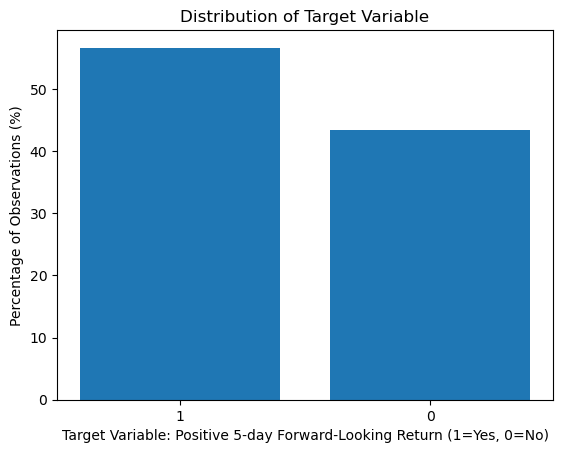

In [30]:
target_value_percentages = target_value_counts / len(data) * 100

plt.bar(target_value_percentages.index.astype(str), target_value_percentages.values)
plt.xlabel("Target Variable: Positive 5-day Forward-Looking Return (1=Yes, 0=No)")
plt.ylabel("Percentage of Observations (%)")
plt.title("Distribution of Target Variable")
plt.show()

The classes are imbalanced and the model could weigh the majority class higher.


In [31]:
answer = "Imbalanced, with the model likely to giver higher weight/importance to the majority class"

#### 2.1.6. Stitching Everything Together

I now add the `vix_data` and `google_trends_daily` as features to `data`. 
I will also rename the column corresponding to the VIX feature. 

In [32]:
# Join with the Google Trends data and VIX data
data = data.join(google_trends_daily, how="left")
data = data.join(vix_data["Adj Close"], how="left")
data.rename(columns={"Adj Close": "vix"}, inplace=True)

### 2.2. Further Data Preprocessing and Cleaning


While engineering new features, some `NaN` values were created. 
I need to clean the combined DataFrame. 
Inspect `data` to see how many `NaN` values there are per column.

In [33]:
data.isna().sum()

month_sin                  0
month_cos                  0
weekday_1                  0
weekday_2                  0
weekday_3                  0
weekday_4                  0
ret_1d_hist                1
ret_5d_hist                5
ret_10d_hist              10
ret_20d_hist              20
log_volume                 0
ibs                        0
bb_bbm                    19
bb_bbh                    19
bb_bbl                    19
bb_bbhi                    0
bb_bbli                    0
bb_bbw                    19
bb_bbp                    19
rsi                       13
tgt_is_pos_ret_5d_fut      0
recession_search_trend    20
vix                        0
dtype: int64

Some features, such as historical returns, RSI, Bollinger Bands and BB indicators 
cannot be calculated for the first `n` days due to their "rolling" nature. 
In general, missing values can sometimes be imputed with reasonable estimates. 
But here I will simply drop the rows containing them. 
The largest `n` is `20`, corresponding to the calculation of 20-day historical returns. 
I will drop the first 20 rows of `data`.


In [34]:
# drop the first 20 days of data (up to but not including idx=20)
data = data.drop(data.index[:20])


Are there any more missing values?

In [35]:
# check for missing values
data.isna().sum()

month_sin                 0
month_cos                 0
weekday_1                 0
weekday_2                 0
weekday_3                 0
weekday_4                 0
ret_1d_hist               0
ret_5d_hist               0
ret_10d_hist              0
ret_20d_hist              0
log_volume                0
ibs                       0
bb_bbm                    0
bb_bbh                    0
bb_bbl                    0
bb_bbhi                   0
bb_bbli                   0
bb_bbw                    0
bb_bbp                    0
rsi                       0
tgt_is_pos_ret_5d_fut     0
recession_search_trend    0
vix                       0
dtype: int64

> **NB:** Remember when calculating the target variable (`tgt_is_pos_ret_5d_fut`), 
> it was based on forward-looking 5-day rolling returns, I could not have known 
> future returns for the last five days of `data`! 
> **Therefore the last 5 rows of data should be dropped.**


In [36]:
# Review the last 10 rows
data.tail(10)

,month_sin,month_cos,weekday_1,weekday_2,weekday_3,weekday_4,ret_1d_hist,ret_5d_hist,ret_10d_hist,ret_20d_hist,log_volume,ibs,bb_bbm,bb_bbh,bb_bbl,bb_bbhi,bb_bbli,bb_bbw,bb_bbp,rsi,tgt_is_pos_ret_5d_fut,recession_search_trend,vix
Date,,,,,,,,,,,,,,,,,,,,,,,
2024-03-15,1.0,6.123234e-17,False,False,False,True,-0.003974,-0.007307,-0.006697,0.001447,16.173578,0.629625,146.183501,147.735278,144.631724,0.0,0.0,2.123054,0.234659,51.606927,0,14.548387,14.41
2024-03-18,1.0,6.123234e-17,False,False,False,False,-0.000117,-0.006881,-0.005318,-0.001903,15.672902,0.117653,146.143501,147.789687,144.497316,0.0,0.0,2.252835,0.098012,48.572318,0,14.258065,14.33
2024-03-19,1.0,6.123234e-17,True,False,False,False,0.006629,-0.004921,0.008801,0.008106,15.471870,0.933336,146.176001,147.765559,144.586443,0.0,0.0,2.174855,0.375436,53.776164,0,14.161290,13.82
2024-03-20,1.0,6.123234e-17,False,True,False,False,-0.002264,-0.003310,-0.000307,0.003611,15.927927,0.941857,146.176001,147.765559,144.586443,0.0,0.0,2.174855,0.271633,51.834474,0,14.064516,13.04
2024-03-21,1.0,6.123234e-17,False,False,True,False,0.001306,0.001548,-0.003641,-0.006755,15.997655,0.361449,146.100001,147.638636,144.561366,0.0,0.0,2.106276,0.350516,52.889197,1,13.967742,12.92
2024-03-22,1.0,6.123234e-17,False,False,False,True,-0.001373,0.004163,-0.003174,-0.012815,15.527000,0.187507,145.979001,147.311830,144.646172,0.0,0.0,1.826056,0.297799,51.608138,1,13.870968,13.06
2024-03-25,1.0,6.123234e-17,False,False,False,False,-0.001375,0.002900,-0.004001,-0.009079,15.474310,0.270599,145.886001,147.150805,144.621197,0.0,0.0,1.733962,0.244626,50.296176,1,13.580645,13.19
2024-03-26,1.0,6.123234e-17,True,False,False,False,0.003649,-0.000069,-0.004990,-0.003023,15.753158,0.787503,145.837501,147.040475,144.634527,0.0,0.0,1.649746,0.471946,53.658283,0,13.483871,13.24
2024-03-27,1.0,6.123234e-17,False,True,False,False,0.013309,0.015538,0.012177,0.015296,15.989967,1.000000,145.922501,147.376307,144.468696,1.0,0.0,1.992572,1.114768,63.413817,1,13.387097,12.78


In [37]:
# drop the last 5 rows of data
data = data.drop(data.tail(5).index)

In [38]:
# confirm the last 5 rows were dropped
data.tail()

,month_sin,month_cos,weekday_1,weekday_2,weekday_3,weekday_4,ret_1d_hist,ret_5d_hist,ret_10d_hist,ret_20d_hist,log_volume,ibs,bb_bbm,bb_bbh,bb_bbl,bb_bbhi,bb_bbli,bb_bbw,bb_bbp,rsi,tgt_is_pos_ret_5d_fut,recession_search_trend,vix
Date,,,,,,,,,,,,,,,,,,,,,,,
2024-03-15,1.0,6.123234e-17,False,False,False,True,-0.003974,-0.007307,-0.006697,0.001447,16.173578,0.629625,146.183501,147.735278,144.631724,0.0,0.0,2.123054,0.234659,51.606927,0,14.548387,14.41
2024-03-18,1.0,6.123234e-17,False,False,False,False,-0.000117,-0.006881,-0.005318,-0.001903,15.672902,0.117653,146.143501,147.789687,144.497316,0.0,0.0,2.252835,0.098012,48.572318,0,14.258065,14.33
2024-03-19,1.0,6.123234e-17,True,False,False,False,0.006629,-0.004921,0.008801,0.008106,15.471870,0.933336,146.176001,147.765559,144.586443,0.0,0.0,2.174855,0.375436,53.776164,0,14.161290,13.82
2024-03-20,1.0,6.123234e-17,False,True,False,False,-0.002264,-0.003310,-0.000307,0.003611,15.927927,0.941857,146.176001,147.765559,144.586443,0.0,0.0,2.174855,0.271633,51.834474,0,14.064516,13.04
2024-03-21,1.0,6.123234e-17,False,False,True,False,0.001306,0.001548,-0.003641,-0.006755,15.997655,0.361449,146.100001,147.638636,144.561366,0.0,0.0,2.106276,0.350516,52.889197,1,13.967742,12.92


Look at the final types and statistical characteristics of the set of features and targets.


In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5069 entries, 2004-02-02 to 2024-03-21
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   month_sin               5069 non-null   float64
 1   month_cos               5069 non-null   float64
 2   weekday_1               5069 non-null   bool   
 3   weekday_2               5069 non-null   bool   
 4   weekday_3               5069 non-null   bool   
 5   weekday_4               5069 non-null   bool   
 6   ret_1d_hist             5069 non-null   float64
 7   ret_5d_hist             5069 non-null   float64
 8   ret_10d_hist            5069 non-null   float64
 9   ret_20d_hist            5069 non-null   float64
 10  log_volume              5069 non-null   float64
 11  ibs                     5069 non-null   float64
 12  bb_bbm                  5069 non-null   float64
 13  bb_bbh                  5069 non-null   float64
 14  bb_bbl                

In [41]:
data.describe().round(3).T

,count,mean,std,min,25%,50%,75%,max
month_sin,5069.0,-0.003,0.710,-1.000,-0.866,-0.000,0.866,1.000
month_cos,5069.0,-0.008,0.705,-1.000,-0.866,-0.000,0.500,1.000
ret_1d_hist,5069.0,0.000,0.010,-0.099,-0.004,0.001,0.006,0.121
ret_5d_hist,5069.0,0.002,0.022,-0.186,-0.009,0.003,0.015,0.192
ret_10d_hist,5069.0,0.004,0.030,-0.217,-0.012,0.006,0.022,0.224
ret_20d_hist,5069.0,0.008,0.040,-0.252,-0.013,0.012,0.033,0.299
log_volume,5069.0,15.409,1.082,10.980,15.158,15.704,16.075,18.012
ibs,5069.0,0.534,0.308,0.000,0.259,0.547,0.818,1.000
bb_bbm,5069.0,65.191,36.491,23.218,32.041,57.274,90.399,146.184
bb_bbh,5069.0,67.148,37.644,24.569,32.789,58.750,93.206,148.369


### 2.3. Correlation Analysis


Correlation analysis can be a rough and early form of feature importance analysis. 
Features that are highly correlated (in either direction) with each other but 
not with the target variable, are a sign of multicollinearity problems, which means 
they may not contribute much additional information in predicting the target. 

In fact, depending on the algorithm used, multicollinearity may result in stability 
and reliability issues. Checking the correlation matrix can be helpful in identifying such features.  

Plot the heatmap of the correlation matrix of features/target and identify a cluster 
of 3 features that are almost certainly collinear. (Hint: `bb_bbm` is one of them.) 
You can pass the correlation matrix directly to [Seaborn's `heatmap()` method](https://seaborn.pydata.org/generated/seaborn.heatmap.html).

<Axes: >

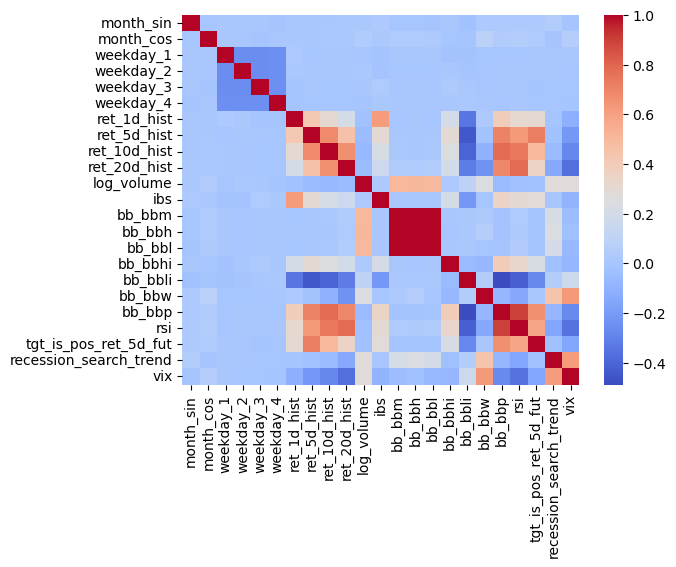

In [42]:
# correlation matrix heatmap
sns.heatmap(data.corr(), cmap="coolwarm")

In such scenarios, we usually eliminate all but one of the collinear features. Keep `bb_bbm` and drop the other two features that are highly linearly related to it.

In [43]:
# drop collinear bollinger band features
drop_cols = ["bb_bbh", "bb_bbl"]
data = data.drop(columns=drop_cols)

There is also one feature that is very highly correlated with `rsi` (which makes intuitive sense, as it, too, is a measure of relative strength). Find it an eliminate it, leaving `rsi` intact.

In [44]:
# drop feature highly correlated with rsi
data = data.drop(columns="bb_bbp")

Plot the heatmap of the new, reduced correlation matrix.

<Axes: >

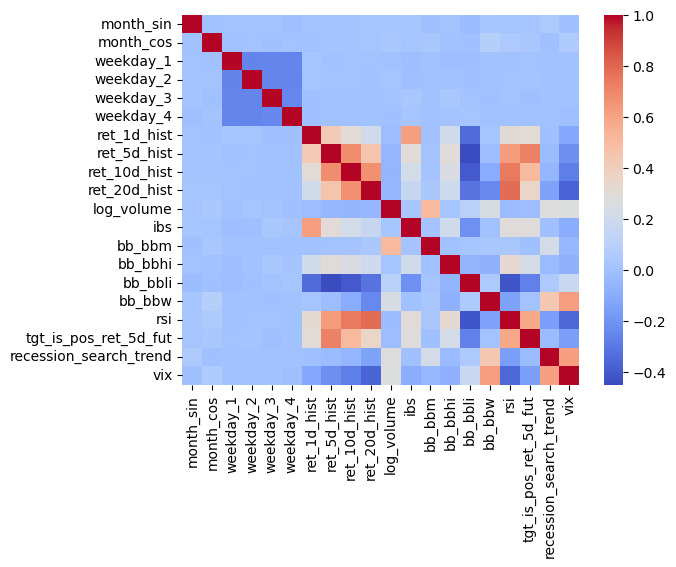

In [45]:
# correlation matrix heatmap
sns.heatmap(data.corr(), cmap="coolwarm")

Features that are highly correlated (negatively or positively) **with the target variable** 
are likely more important. Which two (2) independent variables (features) are 
correlated more than 4% (**in either direction**) with the boolean target variable 
denoting whether 5-day future returns are positive?

In [47]:
np.abs(data.corrwith(data["tgt_is_pos_ret_5d_fut"])) > 0.4

month_sin                 False
month_cos                 False
weekday_1                 False
weekday_2                 False
weekday_3                 False
weekday_4                 False
ret_1d_hist               False
ret_5d_hist                True
ret_10d_hist               True
ret_20d_hist              False
log_volume                False
ibs                       False
bb_bbm                    False
bb_bbhi                   False
bb_bbli                   False
bb_bbw                    False
rsi                        True
tgt_is_pos_ret_5d_fut      True
recession_search_trend    False
vix                       False
dtype: bool

In [48]:
# features with higher than 40% correlation with target
answer = "ret_5d_hist, rsi"

## 3. The Training-Validation-Testing Split


In this section, I split the `data` set into two sets: 
- the training and validation set, and 
- the testing set. 

I then come up with a baseline score so that I have a reference point for evaluating 
the model's performance.

**Note:** Technically, since I am not going to use classical statistics-based time-series 
prediction methods (such as ARIMA), I can shuffle the data before splitting it. 
But for ease of interpretability and backtesting, I will keep the data in its 
original order. This is fine as long as the distributions of features and the 
target variable do not significantly shift over time. 
This is an important assumption related to drift analysis.

### 3.1. The Split


Split the data, temporally, into the training + validation and testing sets. 
Train and optimize (i.e. cross-validate) the model on the first 80% of the data, 
and use the remaining 20% for the test set (i.e. to evaluate the performance of 
the model). 
I use the `train_test_split()` method from scikit-learn's `model_selection` module 
to perform the split.
> **Remember:** Set `shuffle=False` and `random_state=RANDOM_SEED`.

In [49]:
# set the features and target
X = data.drop(columns="tgt_is_pos_ret_5d_fut")
y = data["tgt_is_pos_ret_5d_fut"]

# split the data
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False, random_state=RANDOM_SEED
)

### 3.2. Baseline Model and Score


Analyze at the distribution of the target variable in each split.

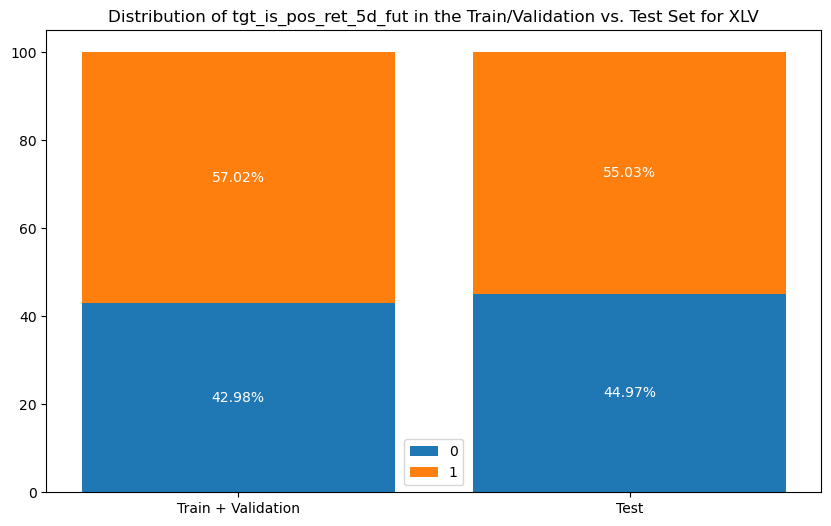

In [50]:
train_val_pct = y_train_val.value_counts(normalize=True) * 100
test_pct = y_test.value_counts(normalize=True) * 100

categories = ["Train + Validation", "Test"]
zero_counts = [train_val_pct[0], test_pct[0]]
one_counts = [train_val_pct[1], test_pct[1]]

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(categories, zero_counts, label="0")
ax.bar(categories, one_counts, bottom=zero_counts, label="1")

# Add text annotations
for i, (zero, one) in enumerate(zip(zero_counts, one_counts)):
    ax.text(i, zero / 2, f"{zero:.2f}%", ha="center", va="center", color="white")
    ax.text(
        i,
        zero + one / 2,
        f"{one:.2f}%",
        ha="center",
        va="center",
        color="white",
    )
ax.set_title(f"Distribution of {target_col_name} in the Train/Validation vs. Test Set for XLV")
ax.legend()

plt.show()

If we were to devise a simple model that naively always predicted the majority 
class, what would the accuracy score be on the training+validation set? 
How about on the testing set? Consider the latter the baseline score, 
i.e. a reference score to compare your more sophisticated model's performace to.

In [ ]:
# Calculate the naive baseline accuracy score
baseline_accuracy_test_score = y_train_val.value_counts().max() / len(y_train_val)
baseline_accuracy_test_score

np.float64(0.5701602959309494)

## 4. Model Training and Tuning


In this section, I train a `RandomForestClassifier`, a robust, versatile ensemble 
learning method that uses "bagging" (also known as "bootstrap aggregating") to 
train multiple Decision Trees. 

The RF model documentation can be found [here](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html).

The below defines a function that plots learning curves annotated with a hyperparameter 
named `max_depth` (maximum depth of the tree).

In [57]:
def plot_learning_curves(train_sizes, train_scores, test_scores, max_depth, axs):
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    axs.fill_between(
        train_sizes,
        train_scores_mean - train_scores_std,
        train_scores_mean + train_scores_std,
        alpha=0.1,
        color="b",
    )
    axs.fill_between(
        train_sizes,
        test_scores_mean - test_scores_std,
        test_scores_mean + test_scores_std,
        alpha=0.1,
        color="r",
    )
    axs.plot(
        train_sizes,
        train_scores_mean,
        "o-",
        color="b",
        label="Average Score on Training Sets",
    )
    axs.plot(
        train_sizes,
        test_scores_mean,
        "o-",
        color="r",
        label="Average Score on Test Sets",
    )
    axs.set_xlabel("Training examples")
    axs.set_ylabel("Score")
    axs.set_title(f"Learning Curves (max_depth={max_depth})")
    axs.legend(loc="center left")
    axs.grid(True)

Below is the first iteration of the model. It uses the default values for most 
of its hyperparameters. 
I have only specified one hyperparameter, `max_depth=10`.

In [58]:
max_depth = 10
# instantiate the RF model
model = RandomForestClassifier(max_depth=max_depth, random_state=RANDOM_SEED, n_jobs=-1)

I use the `learning_curve()` method from scikit-learn's `model_selection` module 
to cross-validate the model, with `accuracy` as the `scoring` metric. 
Using 10%, 20%, 30%,... , and 100% of the training+validatin data, with 5-fold cross-validation.

In [59]:
# cross-validation using sklearn.model_selection.learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    estimator=model,
    X=X_train_val,
    y=y_train_val,
    train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    shuffle=False,
    random_state=RANDOM_SEED
)

Inspect the learning curves.

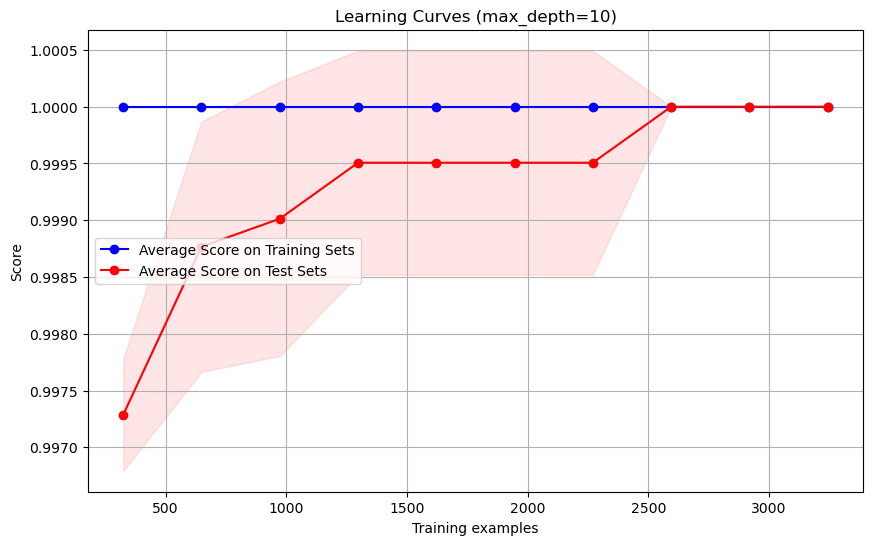

In [60]:
figure = plt.figure(figsize=(10, 6))
axs = figure.gca()

plot_learning_curves(train_sizes, train_scores, test_scores, max_depth, axs)

plt.show()

Wondering what effect different values of the `max_depth` hyperparameter have, 
I experiment with lower (`5`) and higher (`15`) values of it to see how the 
plots change.


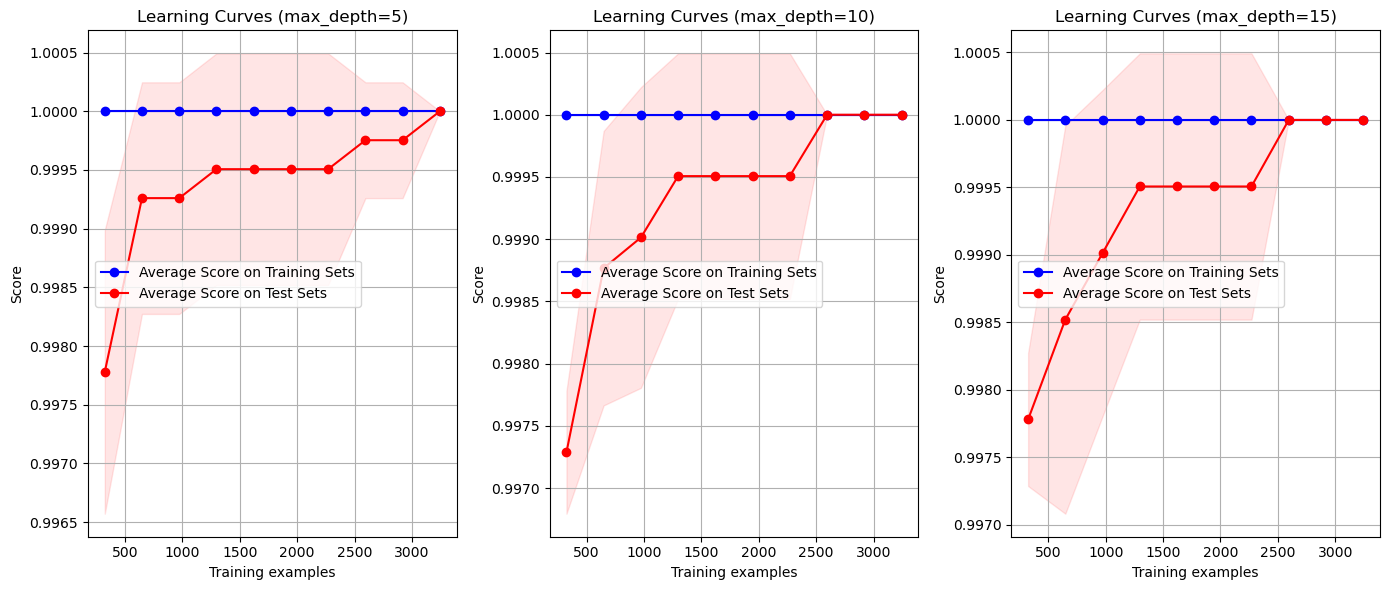

In [65]:
fig, axs = plt.subplots(1, 3, figsize=(14, 6))
max_depth_range = [5, 10, 15]
for i, max_depth in enumerate(max_depth_range):
    model = RandomForestClassifier(max_depth=max_depth, random_state=RANDOM_SEED, n_jobs=-1)
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train_val, y_train_val, train_sizes=train_sizes, cv=5, scoring="accuracy"
    )
    plot_learning_curves(train_sizes, train_scores, test_scores, max_depth, axs[i])

plt.tight_layout()
plt.show()

With a value of `max_depth=15`, the model overfits.


In [64]:
answer = "overfit"

With a value of `max_depth=15`, the accuracy score improves due to higher model complexity.
The tree represents more detailed decision boundaries, bias decreases and variance increases.

In [66]:
answer = "higher model complexity"

Random Forest Classifiers have several other hyperparameters, such as 
- `min_samples_split` (default=2), 
- `min_samples_leaf` (default=1) and 
- `n_estimators` (default=100). 

So far, I've tuned the model manually. But with all the possible combinations of 
hyperparameters, this is not tractable.  

Using grid search cross-validation (the `GridSearchCV` class from scikit-learn's 
`model_selection` module) can find the optimal combination of hyperparameters 
from the search space specified below:
- `max_depth` = 2, 3, 4 or 5
- `min_samples_leaf` = 1, 2, 3 or 4
- `n_estimators` = 50, 75, 100, 125, or 150

As before, I'll use 5-fold cross-validation and accuracy as the `scoring` metric. 
I will name the tuning model `search`.

> Note: Setting `n_jobs=-1` will allow Python to take advantage of parallel computing to speed up the training.

In [ ]:
grid = ## YOUR CODE HERE ##

search = ## YOUR CODE HERE ##

search.fit(## YOUR CODE HERE ##)

Run the cell below to see the top 5 best performing hyperparameter combinations.

In [ ]:
pd.DataFrame(search.cv_results_).sort_values("rank_test_score").head()

Looking at the results of GridSearchCV, which hyperparameters yield the highest mean test score?


In [ ]:
best_max_depth = ## YOUR CODE HERE ##
best_min_samples_leaf = ## YOUR CODE HERE ##
best_n_estimators = ## YOUR CODE HERE ##


Looking more closely at the DataFrame of top 5 results, varying which hyperparameter did not seem to have any effect, at least in the top-ranking score?

In [ ]:
answer = "## YOUR ANSWER HERE ##"

## 5. Model Evaluation and Interpretation


In this section, you will evaluate the performance metrics of the best model you found in the previous section and analyze feature importance in relation to model performance.

### 5.1. Evaluation (Performance Metrics)


It is finally time to train your model on the entire training + validation set with the optimal set of hyperparameters you just found, and evaluate its performance on the test set.  

Train (`fit()`) a `RandomForestClassifier` on the training data with the optimal combination of hyperparameters you found in the previous section. Name it 'clf'.

> **Note:** Remember to set `random_state=RANDOM_SEED` for consistency of results, and set `n_jobs=-1` to automatically speed up the run.

In [ ]:
clf = ## YOUR CODE HERE ##
clf.fit(## YOUR CODE HERE ##)

Store your trained model's predictions on the **testing** set in a variable named `y_test_pred`.

In [ ]:
y_test_pred = ## YOUR CODE HERE ##

Complete the Python dictionary in the code cell below to evaluate your model and answer the questions that follow.

In [ ]:
evaluation = {
    "accuracy": ## YOUR CODE HERE ##,
    "precision": ## YOUR CODE HERE ##,
    "recall": ## YOUR CODE HERE ##,
    "f1": ## YOUR CODE HERE ##,
}
display(evaluation)

Explain, in words and citing the actual numbers from the evaluation report above, what the **precision** and **recall** scores mean.

In [ ]:
answer = "## YOUR ANSWER HERE ##"

Run the cell below to get a more detailed report.

In [ ]:
print(classification_report(y_test, y_test_pred))

How many True Negatives, False Negatives, False Positives and True Positives did the model predict on the test set? Find out using the `confusion_matrix()` method from scikit-learn's `metrics` module. 

In [ ]:
confusion_matrix(y_test, y_test_pred)

Answer the question from earlier.
> Note: Feel free to rename the variables. We will not reference them later.

In [ ]:
num_TrueNeg = ## YOUR CODE HERE ##
num_FalseNeg = ## YOUR CODE HERE ##
num_FalsePos = ## YOUR CODE HERE ##
num_TruePos = ## YOUR CODE HERE ##

Is the model overfitting or underfitting? Did it manage to capture the variance on the training set but fail to generalize to the testing set? Take a look at the `classification_report()` and `confusion_matrix()` on the **training** data.

In [ ]:
y_train_val_pred = ## YOUR CODE HERE ##
print(classification_report(y_train_val, y_train_val_pred))

In [ ]:
confusion_matrix(y_train_val, y_train_val_pred)

How does your model's performance compare to the baseline in terms of `accuracy`?


In [ ]:
answer = "## YOUR ANSWER HERE ##"

How do the `precision` and `recall` of your model compare to those of the baseline model?

In [ ]:
answer = "## YOUR ANSWER HERE ##"

### 5.2. Revisiting Feature Importance


You decide to see if there are any features that are not contributing significantly to the performance of the model. Use the `feature_importances_` property of your classifier.


In [ ]:
## YOUR CODE HERE ##

Create a new training set named `X_train_val_reduced` and a new testing set named `X_test_reduced` by eliminating any features from the old train/test sets that had a feature importance of less than `0.5%`.

In [ ]:
# Drop features that have an importance of 0.05% or less...
feats_to_drop = ## YOUR CODE HERE ##
X_train_val_reduced = ## YOUR CODE HERE ##
X_test_reduced = ## YOUR CODE HERE ##

Re-do your grid search cross-validation with the same grid of hyperparameters as before but with the **reduced** feature set.

In [ ]:
model = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1)

search = ## YOUR CODE HERE ##

search.fit(## YOUR CODE HERE ##)

In [ ]:
pd.DataFrame(search.cv_results_).sort_values("rank_test_score").head()

In [ ]:
search.best_params_

Train a new classifier on the reduced feature set with the best hyperparameters combination from the new grid search and then inspect its accuracy on the test set (with the **reduced** feature set).

In [ ]:
clf = ## YOUR CODE HERE ##
clf.fit(## YOUR CODE HERE ##)

In [ ]:
y_test_pred = ## YOUR CODE HERE ##
evaluation = {
    "accuracy": ## YOUR CODE HERE ##,
    "precision": ## YOUR CODE HERE ##,
    "recall": ## YOUR CODE HERE ##,
    "f1": ## YOUR CODE HERE ##,
}
display(evaluation)

In [ ]:
print(classification_report(y_test, y_test_pred, zero_division=0))

In [ ]:
confusion_matrix(y_test, y_test_pred)

How does the accuracy compare to your last trained model?

In [ ]:
answer = "## YOUR ANSWER HERE ##"

How does the accuracy compare to the baseline?

In [ ]:
answer = "## YOUR ANSWER HERE ##"

Take a look at the classification report and confusion matrices on the **training data** with the **reduced feature set** as well:

In [ ]:
y_train_val_pred = ## YOUR CODE HERE ##
print(classification_report(y_train_val, y_train_val_pred, zero_division=0))

In [ ]:
confusion_matrix(y_train_val, y_train_val_pred)

What would your next course of action be? In particular, share your thoughts on the following:
- Further optimization of this model
- Pursuing a different trading strategy or market (instruments) altogether
- Anything else?

In [ ]:
answer = "## YOUR ANSWER HERE ##"

What do you think of the fact that we used interpolated **monthly** Google Trends data to try and predict short-term (5-day) price movements? 

In [ ]:
answer = "## YOUR ANSWER HERE ##"

## Conclusion

These results highlight the challenges in consistently training AI/ML models that outperform naive baseline scores in financial markets due to factors such as non-stationary data, low signal-to-noise ratio, high market efficiency, and a competitive and adversarial trading environment. It would be necessary to gather much more data (and higher quality data) than we have in this project, and to engineer much more complex features and models to eke out even a slight gain in performance. It is therefore essential to use your domain knowledge, have realistic expectations, and constantly monitor your modeling assumptions and metrics. We hope that this project enables you to do so by giving you the tools, techniques and ideas to keep in mind.